## REGRESSION - Fitting a straight line to the given data

Fitted line: y = 1.9857 * x + 0.0643
Mean Squared Error: 0.0239


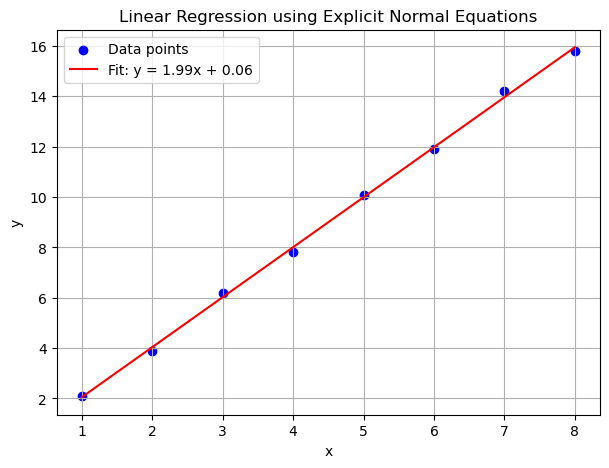

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(2026)


def fit_line_normal_equation(x, y):
    """
    Fit a straight line y = m*x + c to data (x, y) using the
    EXPLICIT normal equations of linear regression (derived by
    setting the partial derivatives of the sum-of-squared-errors
    with respect to m and c to zero).

    For a line y = m*x + c, minimizing S = sum((y_i - m*x_i - c)^2)
    gives the two normal equations:

        (1) sum(y)      = m * sum(x)       + c * n
        (2) sum(x*y)    = m * sum(x^2)     + c * sum(x)

    This is a 2x2 linear system in unknowns (m, c):

        [ sum(x^2)   sum(x) ] [m]   [ sum(x*y) ]
        [ sum(x)     n      ] [c] = [ sum(y)   ]


    Parameters
    ----------
    x : array-like, shape (n,)
    y : array-like, shape (n,)

    Returns
    -------
    m : float  -> slope
    c : float  -> intercept
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    # Compute the required summations
    sum_x  = np.sum(x)
    sum_y  = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x ** 2)

    # Normal equations (2x2 linear system):
    #   sum_x2 * m + sum_x * c = sum_xy      ... (1)
    #   sum_x  * m + n     * c = sum_y       ... (2)
    #
    # Coefficient matrix:
    #   A = [[sum_x2, sum_x],
    #        [sum_x,  n    ]]
    #   B = [sum_xy, sum_y]
    A = np.array([[sum_x2, sum_x],
                  [sum_x,  n]])
    B = np.array([sum_xy, sum_y])

    # Solve the linear system A @ [m, c] = B using np.linalg.solve
    m, c = np.linalg.solve(A, B)

    return m, c


# ----- Example / test data -----
x_data = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y_data = np.array([2.1, 3.9, 6.2, 7.8, 10.1, 11.9, 14.2, 15.8])



# Fit line using explicit normal equations
m, c = fit_line_normal_equation(x_data, y_data)
print(f"Fitted line: y = {m:.4f} * x + {c:.4f}")

# Predictions
y_pred = m * x_data + c

# Mean Squared Error (goodness of fit)
mse = np.mean((y_data - y_pred) ** 2)
print(f"Mean Squared Error: {mse:.4f}")

# ----- Plot -----
plt.figure(figsize=(7, 5))
plt.scatter(x_data, y_data, color="blue", label="Data points")
plt.plot(x_data, y_pred, color="red", label=f"Fit: y = {m:.2f}x + {c:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression using Explicit Normal Equations")
plt.legend()
plt.grid(True)
plt.show()

    

Fitted line: y = 0.9463 * x + -0.5280
Mean Squared Error: 2.6310


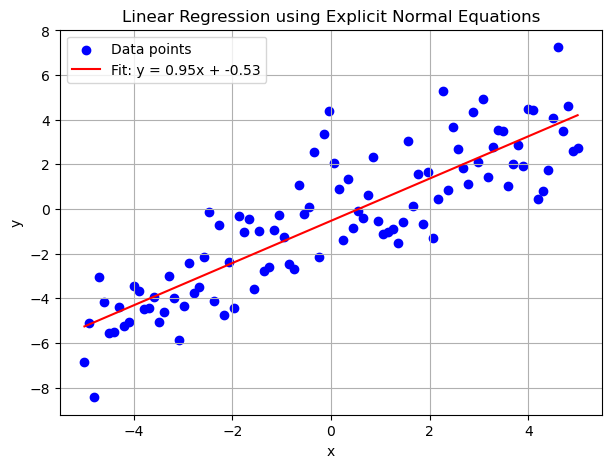

In [2]:
# --- Generate synthetic linear data ---
m_true, c_true = 1.0, -0.6
x_data = np.linspace(-5, 5, 100)
noise_sigma = 1.6
y_data = m_true * x_data + c_true + rng.normal(0.0, noise_sigma, size=x_data.shape)


# Fit line using explicit normal equations
m, c = fit_line_normal_equation(x_data, y_data)
print(f"Fitted line: y = {m:.4f} * x + {c:.4f}")

# Predictions
y_pred = m * x_data + c

# Mean Squared Error (goodness of fit)
mse = np.mean((y_data - y_pred) ** 2)
print(f"Mean Squared Error: {mse:.4f}")

# ----- Plot -----
plt.figure(figsize=(7, 5))
plt.scatter(x_data, y_data, color="blue", label="Data points")
plt.plot(x_data, y_pred, color="red", label=f"Fit: y = {m:.2f}x + {c:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression using Explicit Normal Equations")
plt.legend()
plt.grid(True)
plt.show()

## EXERCISES

1. Fit a straight line for the following data and show a plot of the same.

   
   x = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]

   
   y = [-17, -14, -11, -8, -5, -2, 1, 4, 7, 10]


2. Let $k$ be the last digit of your Roll Number. Fit a straight line for the following data and show a plot of the same.

   
   x = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]

   
   y = [-17, -14+(k-1), -11, -8, -5+(k+1), -2, 1, 4, 7+(k+2), 10]
   

y = 3.0000x + -2.0000


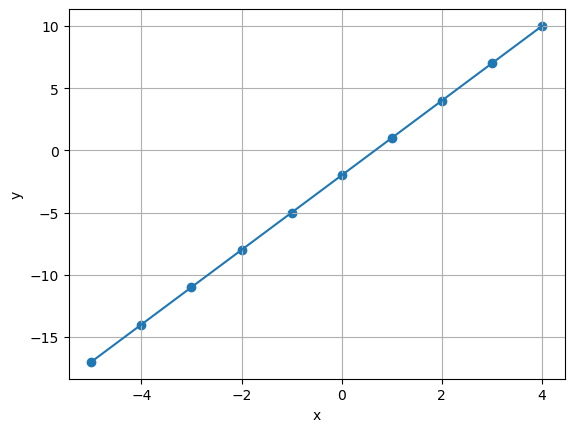

In [3]:
x_data = np.array([-5,-4,-3,-2,-1,0,1,2,3,4])
y_data = np.array([-17,-14,-11,-8,-5,-2,1,4,7,10])

m, c = fit_line_normal_equation(x_data, y_data)

print(f"y = {m:.4f}x + {c:.4f}")

y_pred = m*x_data + c

plt.scatter(x_data, y_data)
plt.plot(x_data, y_pred)
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

y = 3.0667x + 0.9333


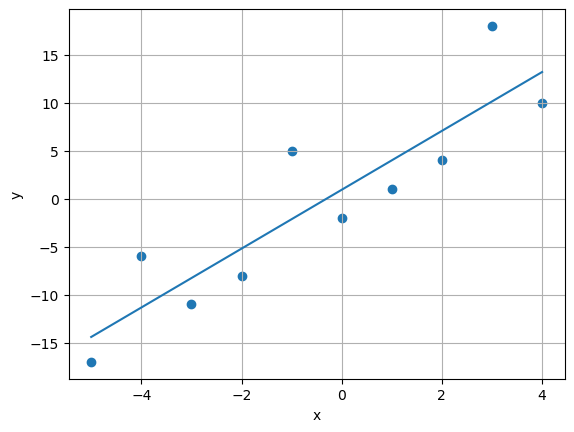

In [5]:
k = 9

x_data = np.array([-5,-4,-3,-2,-1,0,1,2,3,4])
y_data = np.array([
    -17, -14+(k-1), -11, -8, -5+(k+1),
    -2, 1, 4, 7+(k+2), 10
])

m, c = fit_line_normal_equation(x_data, y_data)

print(f"y = {m:.4f}x + {c:.4f}")

y_pred = m*x_data + c

plt.scatter(x_data, y_data)
plt.plot(x_data, y_pred)
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()